# 01 — Exploratory Data Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from scipy import stats

In [2]:
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
# Set display options and plot aesthetics
pd.set_option('display.max_columns', 50)
sns.set_theme(style='darkgrid', palette='muted')

# Define paths for raw data and plots
RAW = Path('../data/raw')
PLOTS = Path('../outputs/plots')
PLOTS.mkdir(parents=True, exist_ok=True)



# Load datasets
genres_v2    = pd.read_csv(RAW / 'dataset_of_songs/genres_v2.csv', low_memory=False)
spotify_2023 = pd.read_csv(RAW / 'spotify_2023/spotify_data_12_20_2023.csv', low_memory=False)
audio_apr_2019    = pd.read_csv(RAW / 'spotify_audio_features/SpotifyAudioFeaturesApril2019.csv')
audio_nov_2018     = pd.read_csv(RAW / 'spotify_audio_features/SpotifyAudioFeaturesNov2018.csv')
sp_tracks    = pd.read_csv(RAW / 'spotify_tracks/dataset.csv', low_memory=False)
ultimate     = pd.read_csv(RAW / 'ultimate_spotify_tracks/SpotifyFeatures.csv')

datasets = {
    'genres_v2'              : genres_v2,
    'spotify_data_2023'      : spotify_2023,
    'audio_features_apr2019' : audio_apr_2019,
    'audio_features_nov2018' : audio_nov_2018,
    'spotify_tracks'         : sp_tracks,
    'ultimate_spotify_tracks': ultimate,
}


In [3]:
# Audio features common across all datasets
AUDIO_FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]

In [4]:
# Check data types of each dataset
for name, df in datasets.items():
    print(f'\n=== {name} ===')
    print(df.dtypes.to_string())


=== genres_v2 ===
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
type                    str
id                      str
uri                     str
track_href              str
analysis_url            str
duration_ms           int64
time_signature        int64
genre                   str
song_name               str
Unnamed: 0          float64
title                   str

=== spotify_data_2023 ===
album_id                 str
album_name               str
album_popularity       int64
album_type               str
artists                  str
artist_0                 str
artist_1                 str
artist_2                 str
artist_3                 str
artist_4                 str
artist_id                str
duration_sec       


█████████████████████████████████████████████████████████████████
  DATASET: genres_v2
█████████████████████████████████████████████████████████████████

  📐 Shape: 42,305 rows x 22 cols

  📋 Columns & Data Types:
  Column                                   Dtype
  ---------------------------------------------
  danceability                           float64
  energy                                 float64
  key                                      int64
  loudness                               float64
  mode                                     int64
  speechiness                            float64
  acousticness                           float64
  instrumentalness                       float64
  liveness                               float64
  valence                                float64
  tempo                                  float64
  type                                       str
  id                                         str
  uri                                        str
  

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,id,uri,track_href,analysis_url,duration_ms,time_signature,genre,song_name,Unnamed: 0,title
0,0.831,0.814,2,-7.364,1,0.4200,0.0598,0.013400,0.0556,0.3890,156.985,audio_features,2Vc6NJ9PW9gD9q343XFRKx,spotify:track:2Vc6NJ9PW9gD9q343XFRKx,https://api.spotify.com/v1/tracks/2Vc6NJ9PW9gD...,https://api.spotify.com/v1/audio-analysis/2Vc6...,124539,4,Dark Trap,Mercury: Retrograde,NaN,NaN
1,0.719,0.493,8,-7.230,1,0.0794,0.4010,0.000000,0.1180,0.1240,115.080,audio_features,7pgJBLVz5VmnL7uGHmRj6p,spotify:track:7pgJBLVz5VmnL7uGHmRj6p,https://api.spotify.com/v1/tracks/7pgJBLVz5Vmn...,https://api.spotify.com/v1/audio-analysis/7pgJ...,224427,4,Dark Trap,Pathology,NaN,NaN
2,0.850,0.893,5,-4.783,1,0.0623,0.0138,0.000004,0.3720,0.0391,218.050,audio_features,0vSWgAlfpye0WCGeNmuNhy,spotify:track:0vSWgAlfpye0WCGeNmuNhy,https://api.spotify.com/v1/tracks/0vSWgAlfpye0...,https://api.spotify.com/v1/audio-analysis/0vSW...,98821,4,Dark Trap,Symbiote,NaN,NaN



  ❓ Missing Values:
  Column                                   Count      Pct
  -------------------------------------------------------
  Unnamed: 0                              21,525   50.88%
  title                                   21,525   50.88%
  song_name                               20,786   49.13%

  🔁 Duplicate rows: 0 (0.00%)

  📊 Audio Feature Statistics:
  Feature                  Mean     Mode   Median      Std      Min      Max
  --------------------------------------------------------------------
  danceability            0.639    0.804    0.646    0.157    0.065    0.988
  energy                  0.763    0.977    0.803    0.184    0.000    1.000
  loudness               -6.465   -6.186   -6.234    2.941  -33.357    3.148
  speechiness             0.137    0.102    0.075    0.126    0.023    0.946
  acousticness            0.096    0.128    0.016    0.171    0.000    0.988
  instrumentalness        0.283    0.000    0.006    0.371    0.000    0.989
  liveness       

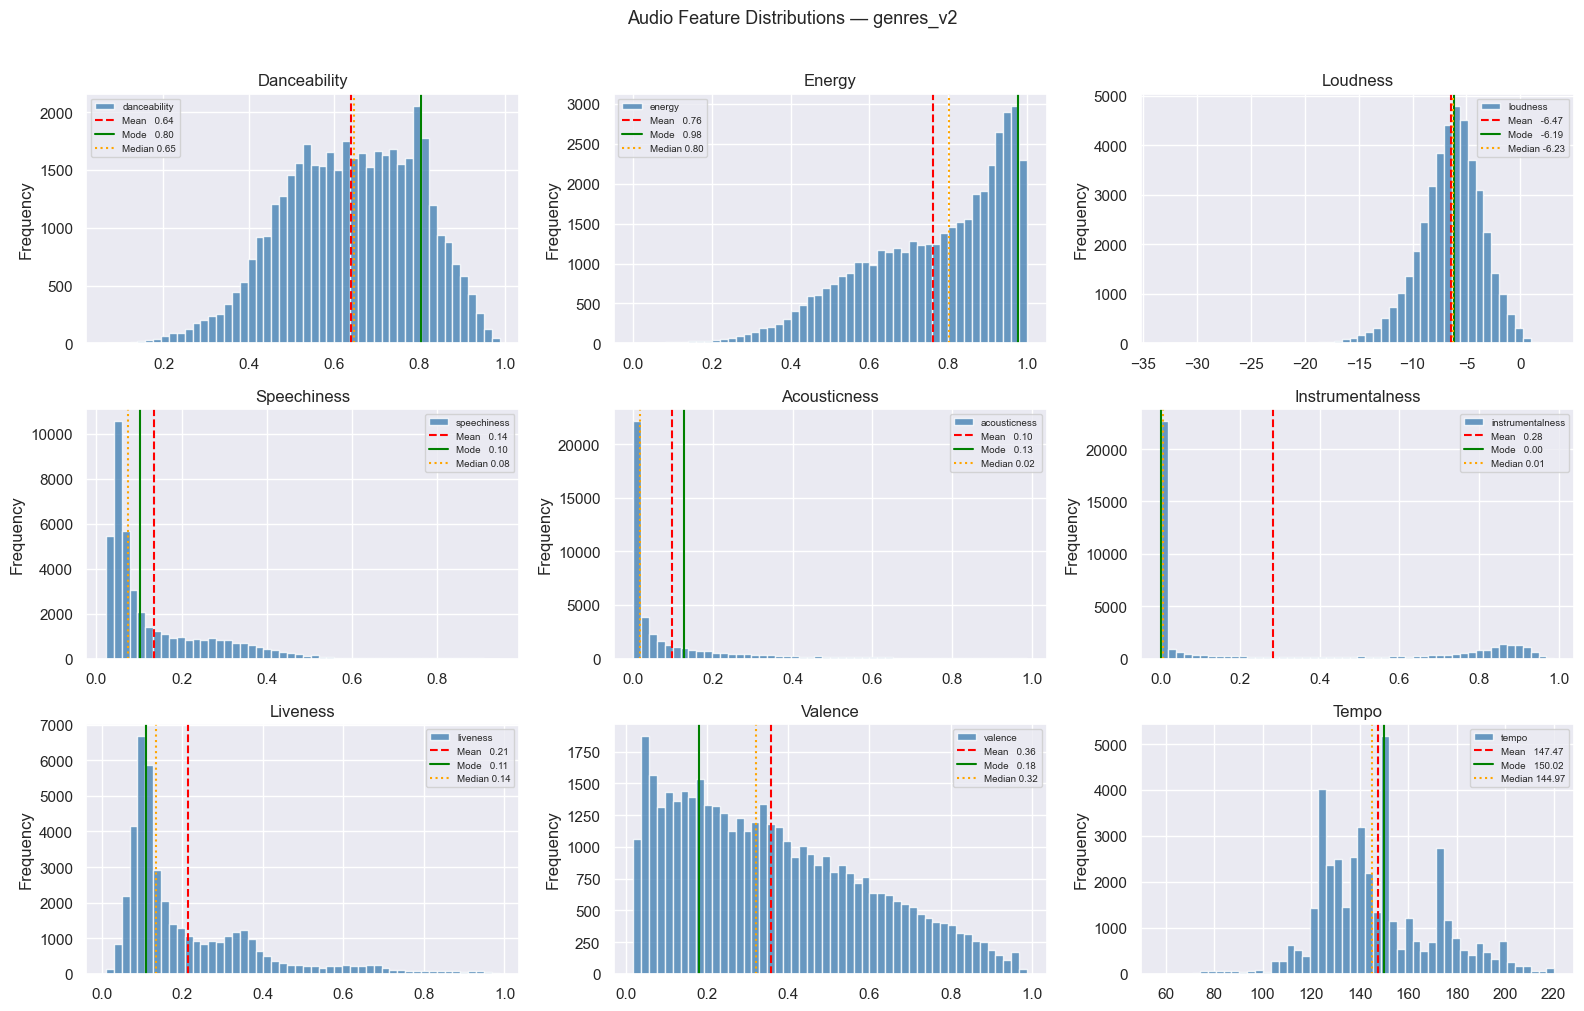

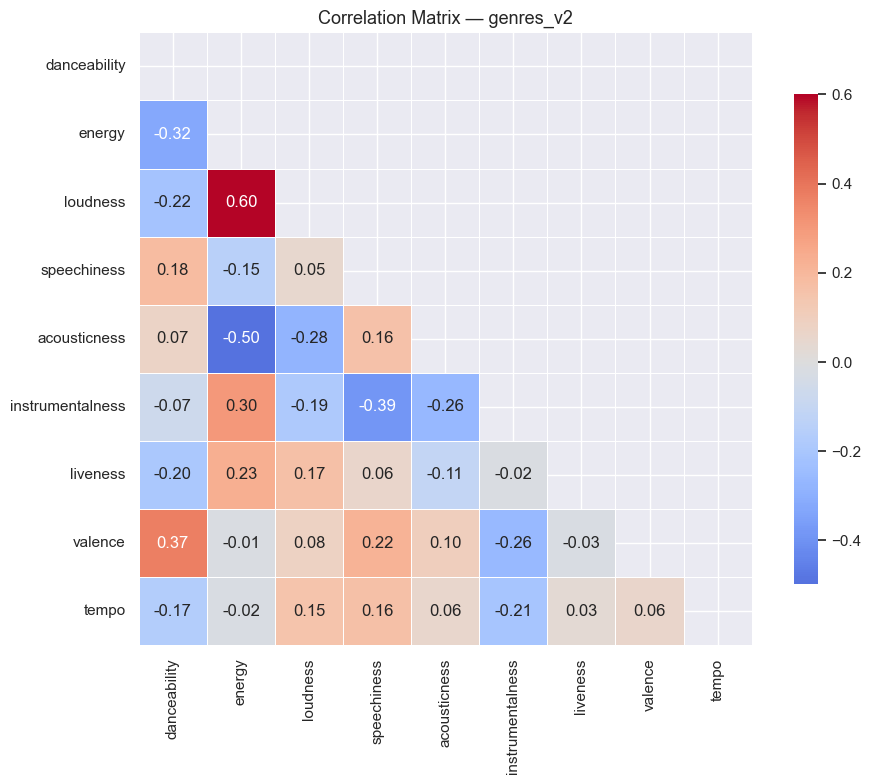


─────────────────────────────────────────────────────────────────


█████████████████████████████████████████████████████████████████
  DATASET: spotify_data_2023
█████████████████████████████████████████████████████████████████

  📐 Shape: 375,141 rows x 49 cols

  📋 Columns & Data Types:
  Column                                   Dtype
  ---------------------------------------------
  album_id                                   str
  album_name                                 str
  album_popularity                         int64
  album_type                                 str
  artists                                    str
  artist_0                                   str
  artist_1                                   str
  artist_2                                   str
  artist_3                                   str
  artist_4                                   str
  artist_id                                  str
  duration_sec                           float64
  label                

,album_id,album_name,album_popularity,album_type,artists,artist_0,artist_1,artist_2,artist_3,artist_4,artist_id,duration_sec,label,release_date,total_tracks,track_id,track_name,track_number,artist_genres,artist_popularity,followers,name,genre_0,genre_1,genre_2,genre_3,genre_4,acousticness,analysis_url,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,track_href,type,uri,valence,explicit,track_popularity,release_year,release_month,rn
0,4zH8bbEjLe0Gdbv2FVLjnK,Son Of Tabu,1,album,['AB'],AB,NaN,NaN,NaN,NaN,08jcfs5JspUBqM3rbFNUzm,92.063,About Benjamin Records,2023-04-15 00:00:00 UTC,8,5JucnTkqh8uCZGggL1xxvv,Intro,1,[],0,133,AB,NaN,NaN,NaN,NaN,NaN,0.0305,https://api.spotify.com/v1/audio-analysis/5Juc...,0.622,92064.0,0.554,0.000001,5.0,0.392,-9.505,0.0,0.414,72.546,4.0,https://api.spotify.com/v1/tracks/5JucnTkqh8uC...,audio_features,spotify:track:5JucnTkqh8uCZGggL1xxvv,0.382,True,0.0,2023.0,April,1
1,4zH8bbEjLe0Gdbv2FVLjnK,Son Of Tabu,1,album,"['AB', '22nd Jim']",AB,22nd Jim,NaN,NaN,NaN,08jcfs5JspUBqM3rbFNUzm,125.320,About Benjamin Records,2023-04-15 00:00:00 UTC,8,4VWrKNG3ssyZeboTgQ7Kj1,Play It Cool,5,[],0,133,AB,NaN,NaN,NaN,NaN,NaN,0.0112,https://api.spotify.com/v1/audio-analysis/4VWr...,0.899,125320.0,0.701,0.000000,11.0,0.153,-6.182,0.0,0.138,101.581,4.0,https://api.spotify.com/v1/tracks/4VWrKNG3ssyZ...,audio_features,spotify:track:4VWrKNG3ssyZeboTgQ7Kj1,0.193,True,1.0,2023.0,April,1
2,4zH8bbEjLe0Gdbv2FVLjnK,Son Of Tabu,1,album,"['AB', 'Veeze']",AB,Veeze,NaN,NaN,NaN,08jcfs5JspUBqM3rbFNUzm,139.800,About Benjamin Records,2023-04-15 00:00:00 UTC,8,6JsVrTLJPSOSpgJSnZyfSK,3 Peat,3,[],0,133,AB,NaN,NaN,NaN,NaN,NaN,0.0815,https://api.spotify.com/v1/audio-analysis/6JsV...,0.782,139800.0,0.716,0.000000,10.0,0.126,-8.295,0.0,0.382,99.789,4.0,https://api.spotify.com/v1/tracks/6JsVrTLJPSOS...,audio_features,spotify:track:6JsVrTLJPSOSpgJSnZyfSK,0.835,True,1.0,2023.0,April,1



  ❓ Missing Values:
  Column                                   Count      Pct
  -------------------------------------------------------
  artist_4                               369,054   98.38%
  artist_3                               361,318   96.32%
  genre_4                                343,824   91.65%
  artist_2                               336,841   89.79%
  genre_3                                326,531   87.04%
  genre_2                                297,922   79.42%
  artist_1                               288,062   76.79%
  genre_1                                255,655   68.15%
  genre_0                                165,278   44.06%
  danceability                               777    0.21%
  analysis_url                               777    0.21%
  acousticness                               777    0.21%
  mode                                       777    0.21%
  speechiness                                777    0.21%
  instrumentalness                           777   

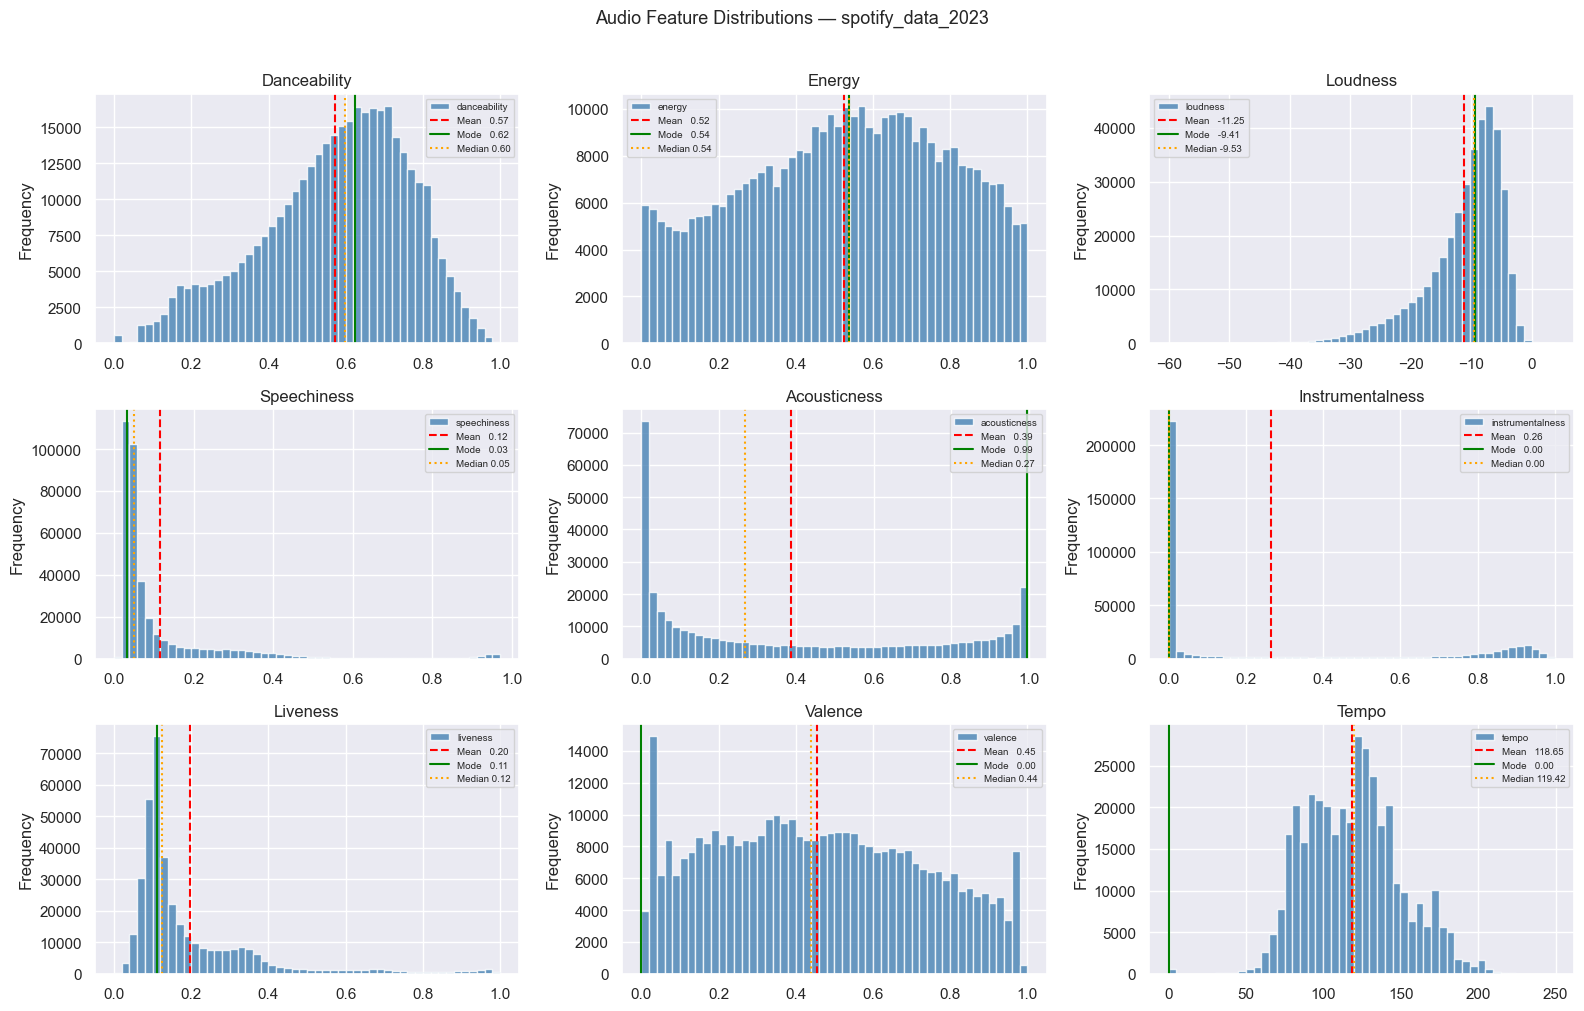

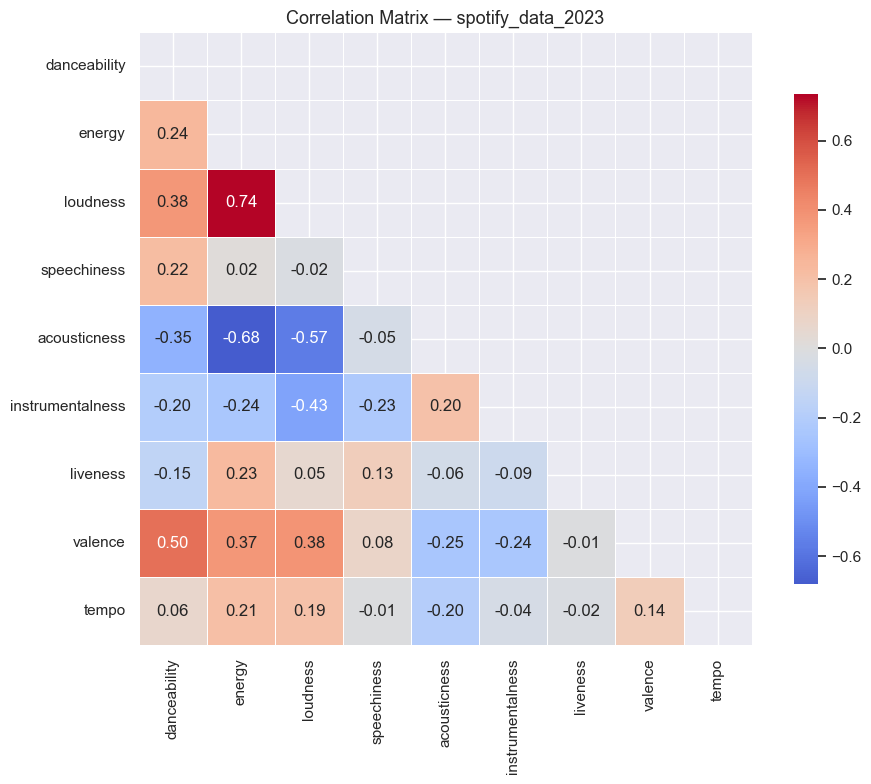


─────────────────────────────────────────────────────────────────


█████████████████████████████████████████████████████████████████
  DATASET: audio_features_apr2019
█████████████████████████████████████████████████████████████████

  📐 Shape: 130,663 rows x 17 cols

  📋 Columns & Data Types:
  Column                                   Dtype
  ---------------------------------------------
  artist_name                                str
  track_id                                   str
  track_name                                 str
  acousticness                           float64
  danceability                           float64
  duration_ms                              int64
  energy                                 float64
  instrumentalness                       float64
  key                                      int64
  liveness                               float64
  loudness                               float64
  mode                                     int64
  speechiness     

,artist_name,track_id,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity
0,YG,2RM4jf1Xa9zPgMGRDiht8O,"Big Bank feat. 2 Chainz, Big Sean, Nicki Minaj",0.00582,0.743,238373,0.339,0.0,1,0.0812,-7.678,1,0.4090,203.927,4,0.118,15
1,YG,1tHDG53xJNGsItRA3vfVgs,BAND DRUM (feat. A$AP Rocky),0.02440,0.846,214800,0.557,0.0,8,0.2860,-7.259,1,0.4570,159.009,4,0.371,0
2,R3HAB,6Wosx2euFPMT14UXiWudMy,Radio Silence,0.02500,0.603,138913,0.723,0.0,9,0.0824,-5.890,0,0.0454,114.966,4,0.382,56



  ❓ Missing Values:
  Column                                   Count      Pct
  -------------------------------------------------------
  track_name                                   1    0.00%

  🔁 Duplicate rows: 0 (0.00%)

  📊 Audio Feature Statistics:
  Feature                  Mean     Mode   Median      Std      Min      Max
  --------------------------------------------------------------------
  danceability            0.581    0.664    0.605    0.190    0.000    0.996
  energy                  0.569    0.666    0.603    0.260    0.000    1.000
  loudness               -9.974   -6.246   -7.979    6.544  -60.000    1.806
  speechiness             0.112    0.038    0.056    0.124    0.000    0.966
  acousticness            0.343    0.995    0.203    0.346    0.000    0.996
  instrumentalness        0.224    0.000    0.000    0.360    0.000    1.000
  liveness                0.195    0.111    0.124    0.168    0.000    0.999
  valence                 0.440    0.000    0.420    0.2

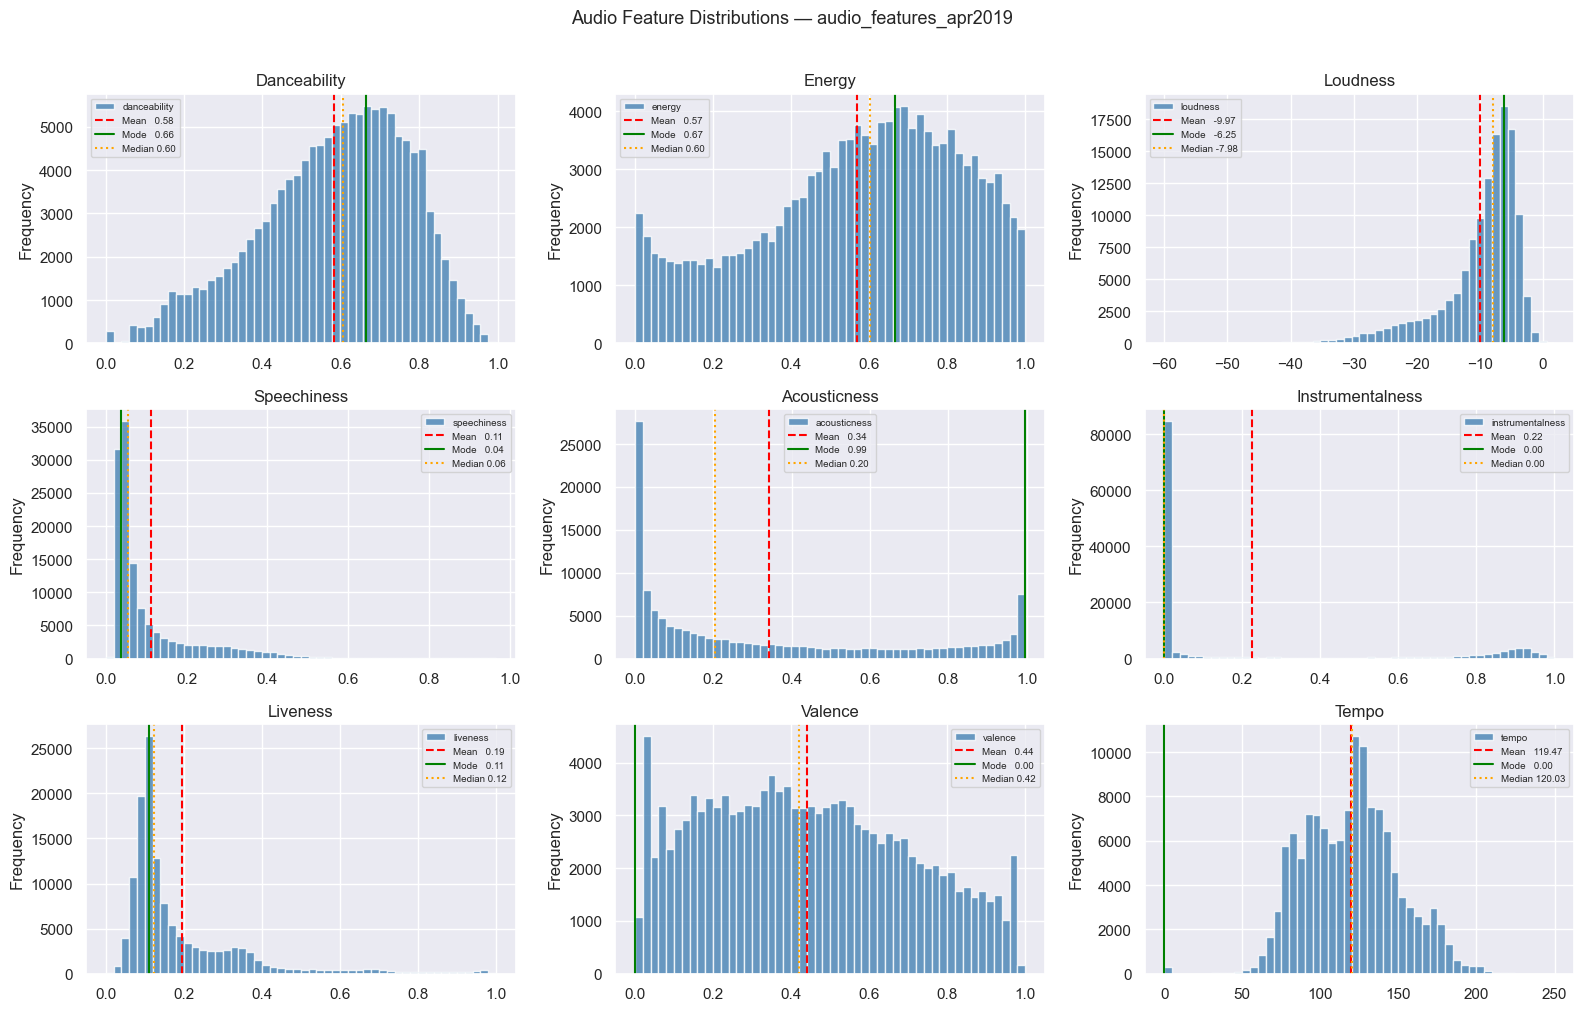

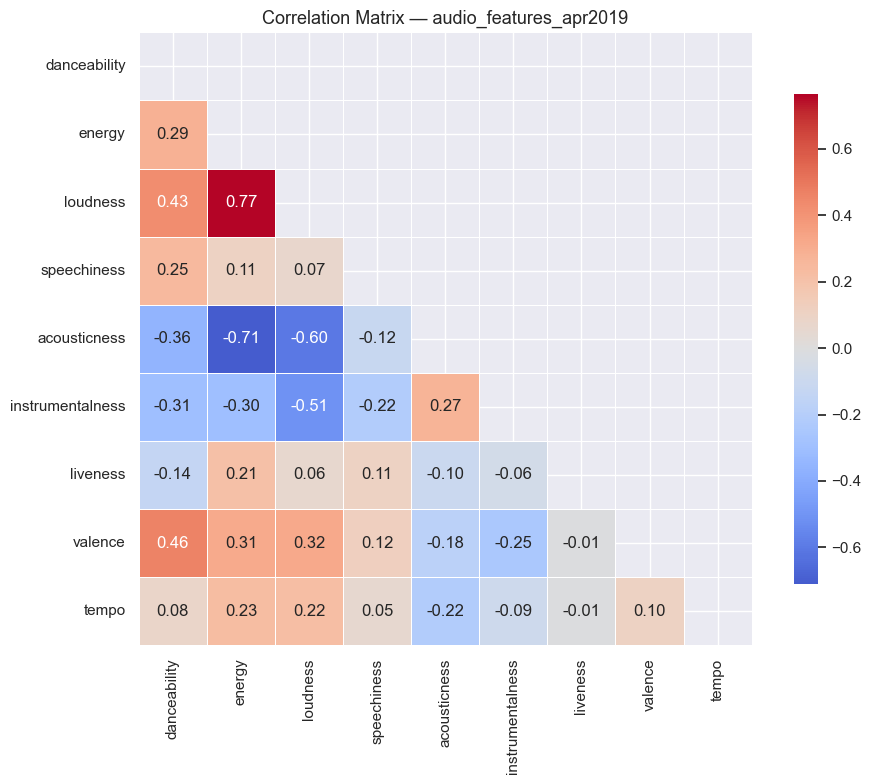


─────────────────────────────────────────────────────────────────


█████████████████████████████████████████████████████████████████
  DATASET: audio_features_nov2018
█████████████████████████████████████████████████████████████████

  📐 Shape: 116,372 rows x 17 cols

  📋 Columns & Data Types:
  Column                                   Dtype
  ---------------------------------------------
  artist_name                                str
  track_id                                   str
  track_name                                 str
  acousticness                           float64
  danceability                           float64
  duration_ms                              int64
  energy                                 float64
  instrumentalness                       float64
  key                                      int64
  liveness                               float64
  loudness                               float64
  mode                                     int64
  speechiness     

,artist_name,track_id,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity
0,YG,2RM4jf1Xa9zPgMGRDiht8O,"Big Bank feat. 2 Chainz, Big Sean, Nicki Minaj",0.00582,0.743,238373,0.339,0.0,1,0.0812,-7.678,1,0.4090,203.927,4,0.118,44
1,YG,1tHDG53xJNGsItRA3vfVgs,BAND DRUM (feat. A$AP Rocky),0.02440,0.846,214800,0.557,0.0,8,0.2860,-7.259,1,0.4570,159.009,4,0.371,10
2,R3HAB,6Wosx2euFPMT14UXiWudMy,Radio Silence,0.02500,0.603,138913,0.723,0.0,9,0.0824,-5.890,0,0.0454,114.966,4,0.382,63



  ❓ Missing Values:
  Column                                   Count      Pct
  -------------------------------------------------------
  track_name                                   1    0.00%

  🔁 Duplicate rows: 0 (0.00%)

  📊 Audio Feature Statistics:
  Feature                  Mean     Mode   Median      Std      Min      Max
  --------------------------------------------------------------------
  danceability            0.582    0.750    0.606    0.190    0.000    0.996
  energy                  0.572    0.666    0.605    0.259    0.000    1.000
  loudness               -9.945   -6.246   -7.992    6.504  -60.000    1.806
  speechiness             0.112    0.038    0.056    0.124    0.000    0.966
  acousticness            0.335    0.995    0.194    0.343    0.000    0.996
  instrumentalness        0.230    0.000    0.000    0.363    0.000    1.000
  liveness                0.194    0.111    0.123    0.167    0.000    0.999
  valence                 0.438    0.000    0.419    0.2

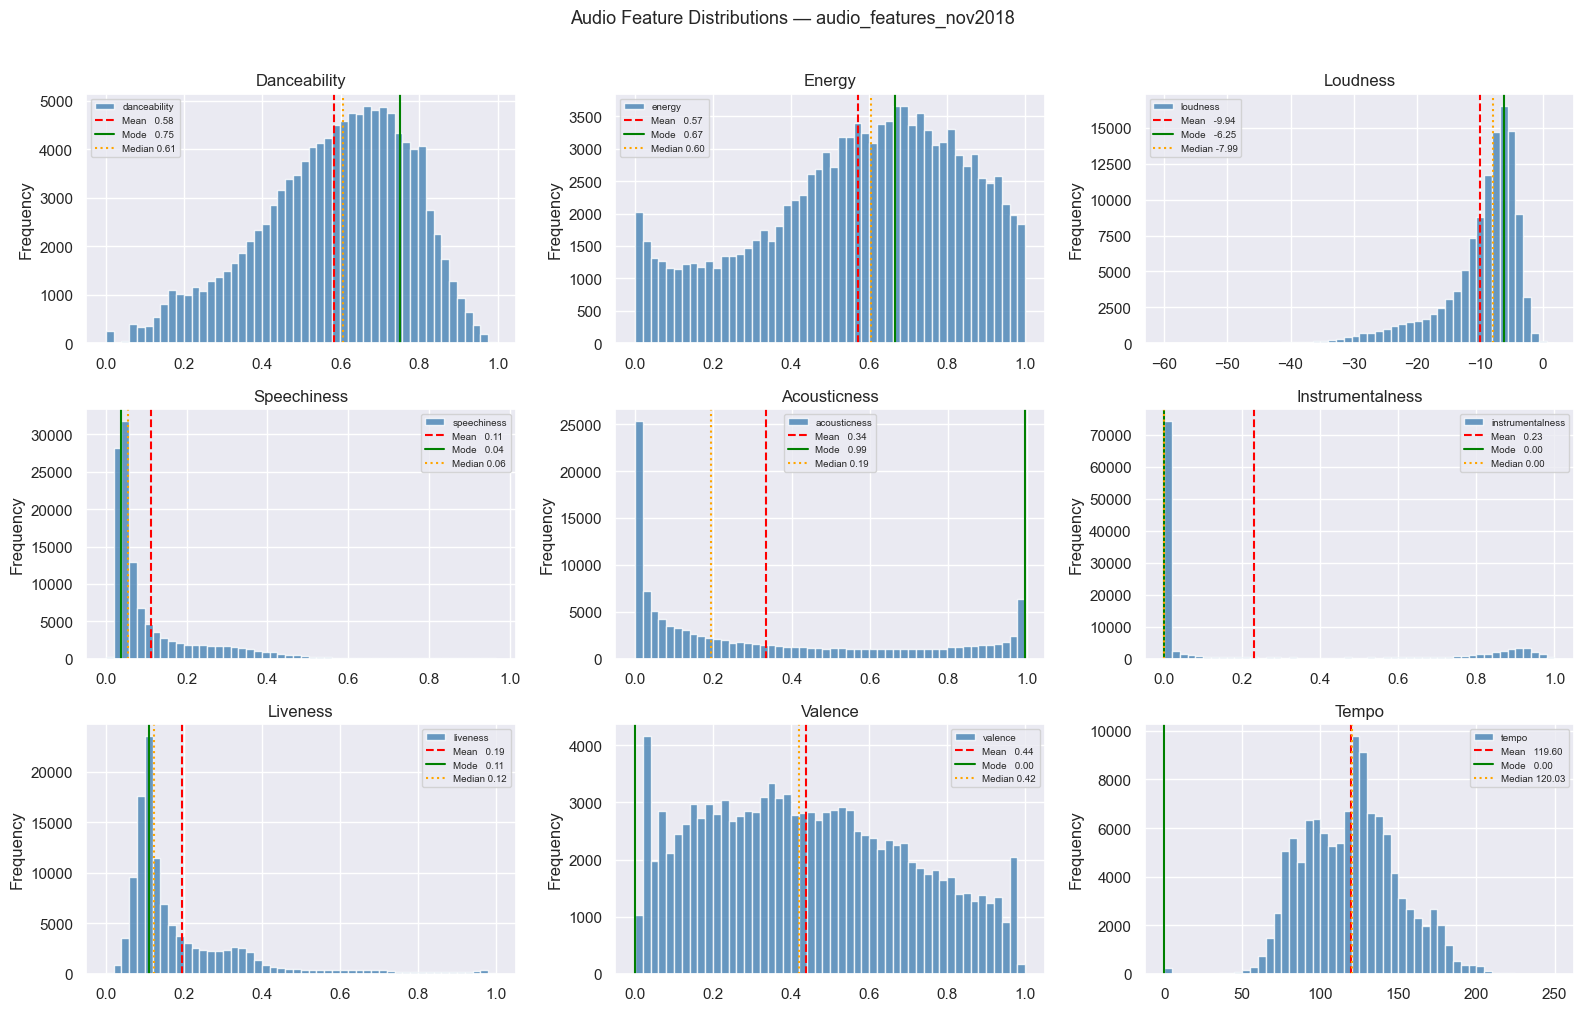

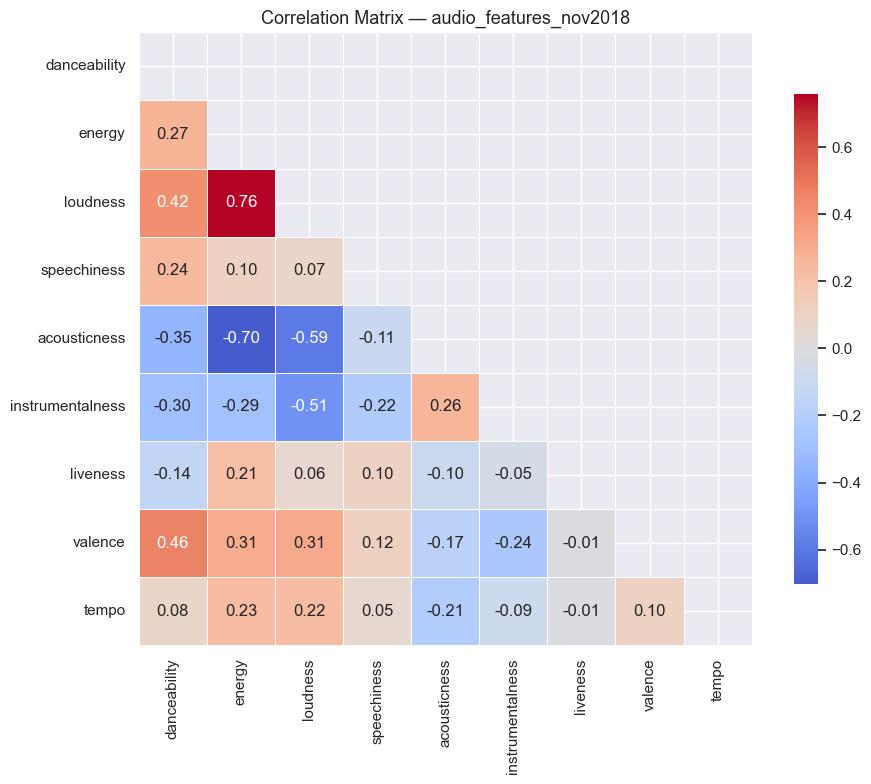


─────────────────────────────────────────────────────────────────


█████████████████████████████████████████████████████████████████
  DATASET: spotify_tracks
█████████████████████████████████████████████████████████████████

  📐 Shape: 114,000 rows x 21 cols

  📋 Columns & Data Types:
  Column                                   Dtype
  ---------------------------------------------
  Unnamed: 0                               int64
  track_id                                   str
  artists                                    str
  album_name                                 str
  track_name                                 str
  popularity                               int64
  duration_ms                              int64
  explicit                                  bool
  danceability                           float64
  energy                                 float64
  key                                      int64
  loudness                               float64
  mode                    

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic



  ❓ Missing Values:
  Column                                   Count      Pct
  -------------------------------------------------------
  artists                                      1    0.00%
  track_name                                   1    0.00%
  album_name                                   1    0.00%

  🔁 Duplicate rows: 0 (0.00%)

  📊 Audio Feature Statistics:
  Feature                  Mean     Mode   Median      Std      Min      Max
  --------------------------------------------------------------------
  danceability            0.567    0.647    0.580    0.174    0.000    0.985
  energy                  0.641    0.876    0.685    0.252    0.000    1.000
  loudness               -8.259   -5.662   -7.004    5.029  -49.531    4.532
  speechiness             0.085    0.032    0.049    0.106    0.000    0.965
  acousticness            0.315    0.995    0.169    0.333    0.000    0.996
  instrumentalness        0.156    0.000    0.000    0.310    0.000    1.000
  liveness       

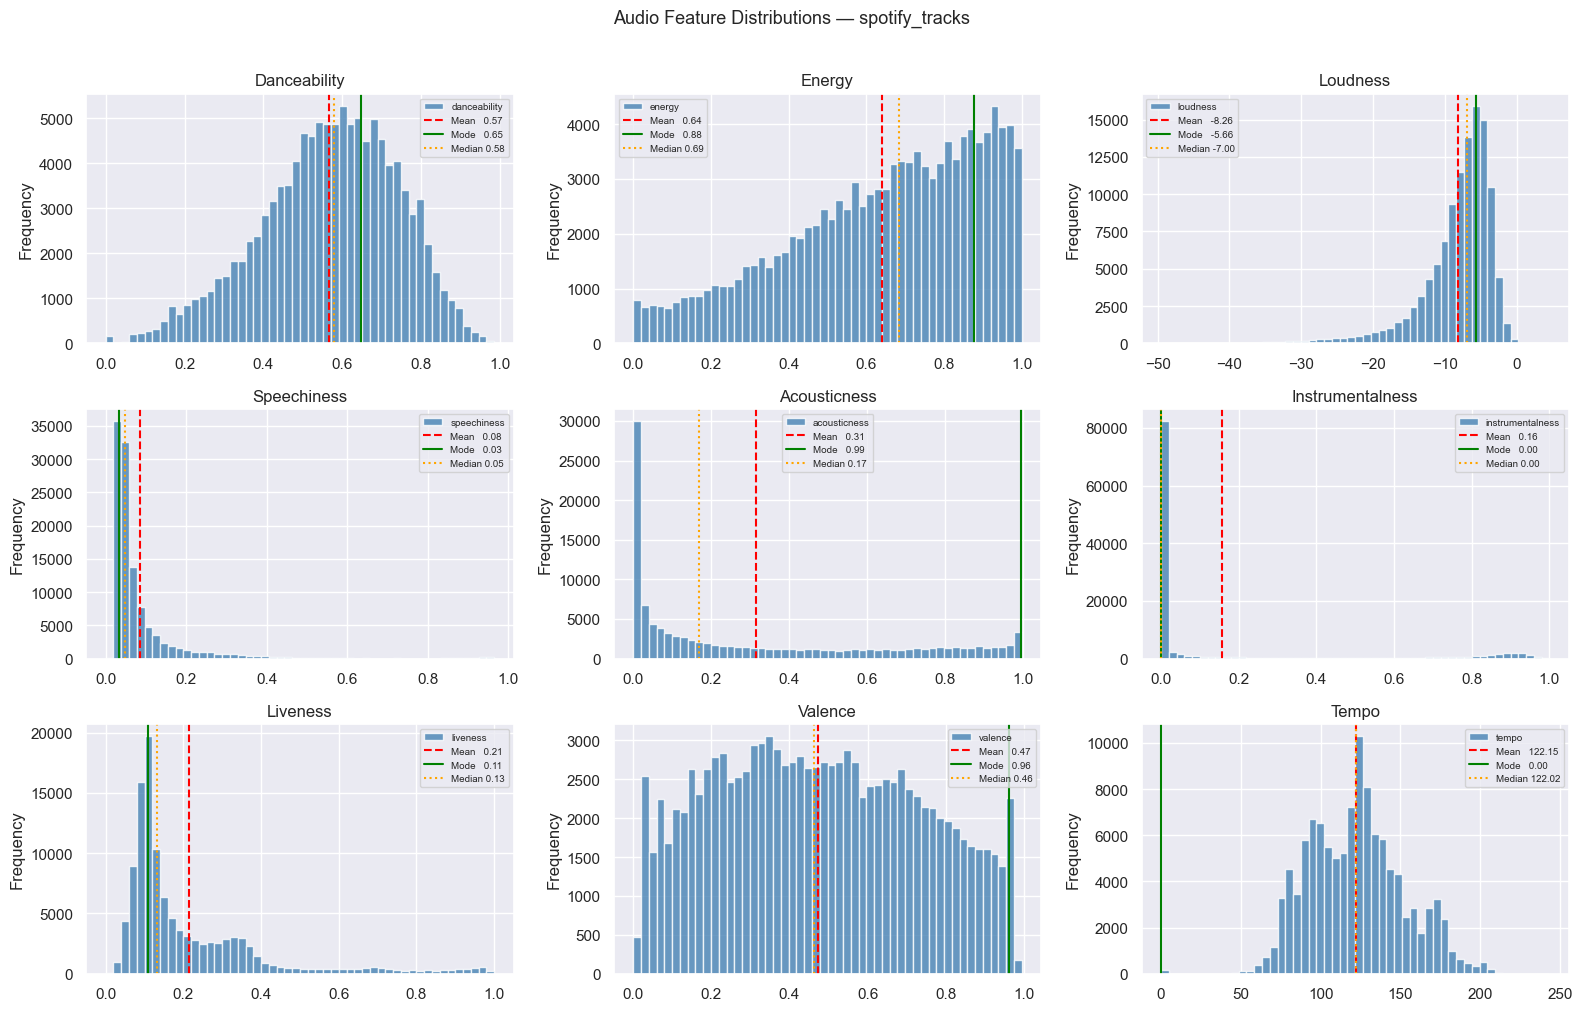

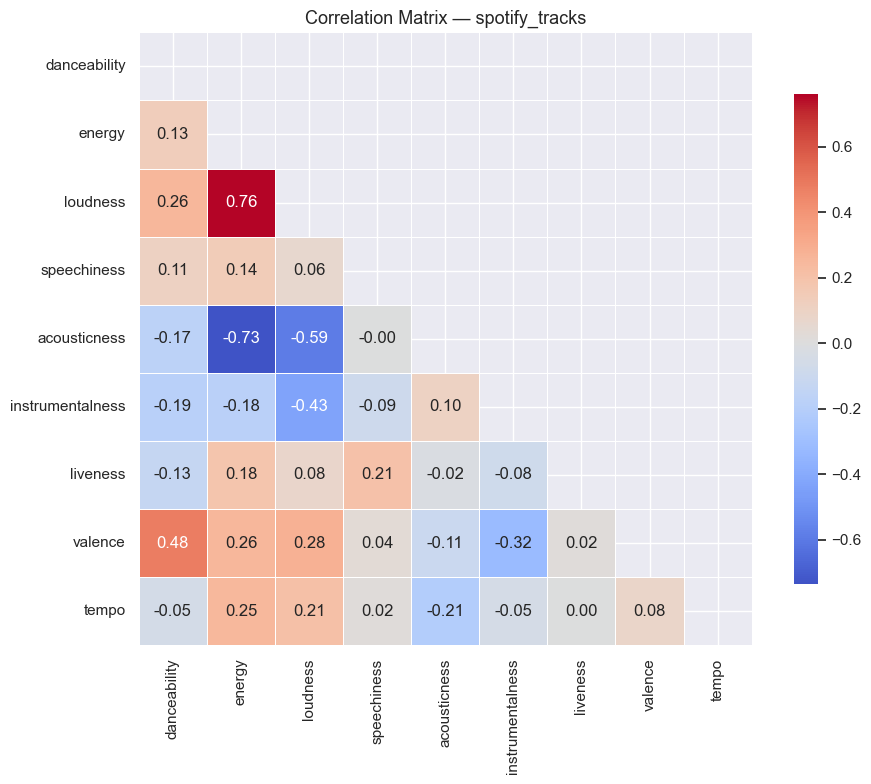


─────────────────────────────────────────────────────────────────


█████████████████████████████████████████████████████████████████
  DATASET: ultimate_spotify_tracks
█████████████████████████████████████████████████████████████████

  📐 Shape: 232,725 rows x 18 cols

  📋 Columns & Data Types:
  Column                                   Dtype
  ---------------------------------------------
  genre                                      str
  artist_name                                str
  track_name                                 str
  track_id                                   str
  popularity                               int64
  acousticness                           float64
  danceability                           float64
  duration_ms                              int64
  energy                                 float64
  instrumentalness                       float64
  key                                        str
  liveness                               float64
  loudness       

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.0,C#,0.346,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.0,F#,0.151,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.0,C,0.103,-13.879,Minor,0.0362,99.488,5/4,0.368



  ❓ Missing Values:
  Column                                   Count      Pct
  -------------------------------------------------------
  track_name                                   1    0.00%

  🔁 Duplicate rows: 0 (0.00%)

  📊 Audio Feature Statistics:
  Feature                  Mean     Mode   Median      Std      Min      Max
  --------------------------------------------------------------------
  danceability            0.554    0.597    0.571    0.186    0.057    0.989
  energy                  0.571    0.721    0.605    0.263    0.000    0.999
  loudness               -9.570   -5.318   -7.762    5.998  -52.457    3.744
  speechiness             0.121    0.037    0.050    0.186    0.022    0.967
  acousticness            0.369    0.995    0.232    0.355    0.000    0.996
  instrumentalness        0.148    0.000    0.000    0.303    0.000    0.999
  liveness                0.215    0.111    0.128    0.198    0.010    1.000
  valence                 0.455    0.961    0.444    0.2

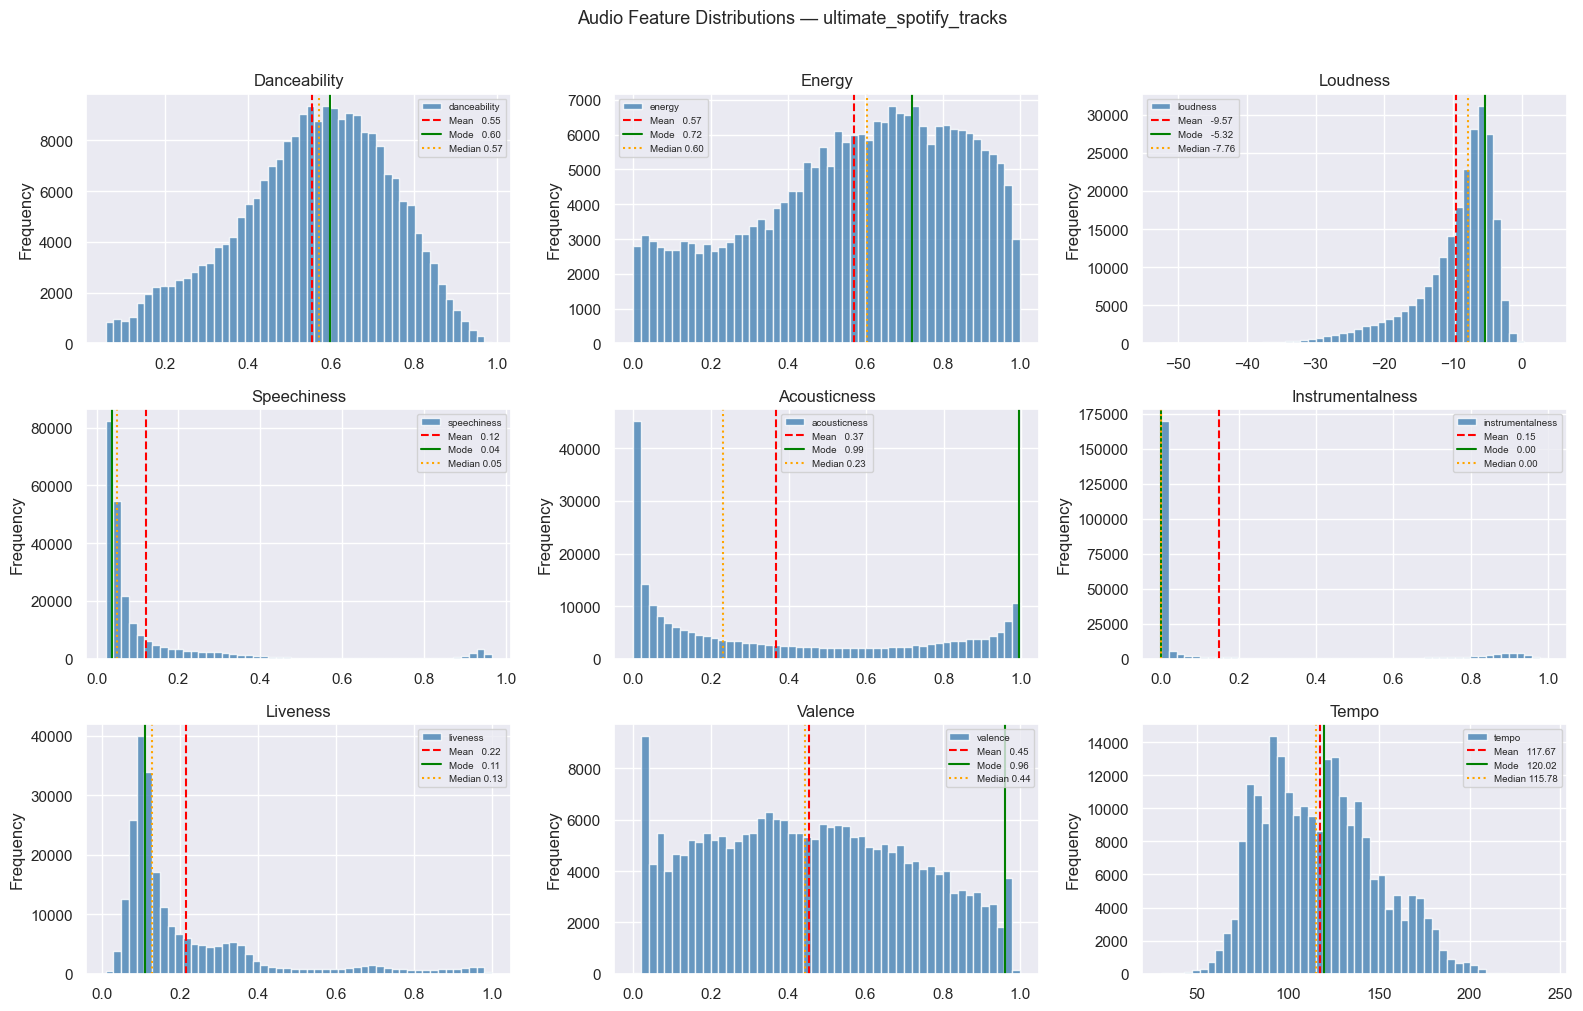

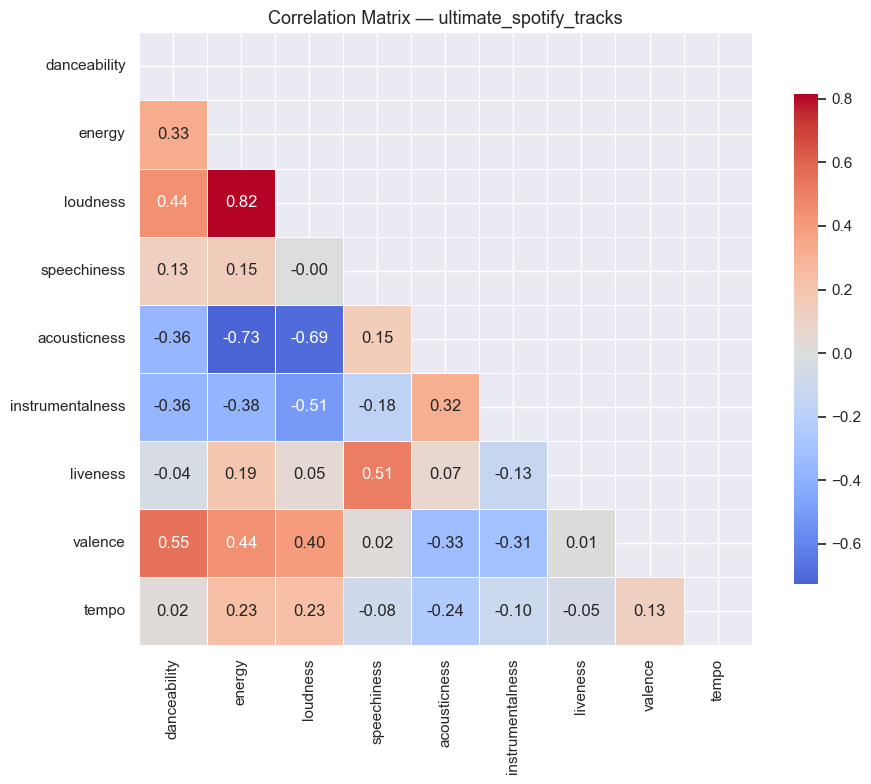


─────────────────────────────────────────────────────────────────



In [5]:
# ── EDA per Dataset ──────────────────────────────────────────────

for name, df in datasets.items():
    print(f'\n{"█"*65}')
    print(f'  DATASET: {name}')
    print(f'{"█"*65}')

    # ── 1. Shape ────────────────────────────────────────────────
    print(f'\n  📐 Shape: {df.shape[0]:,} rows x {df.shape[1]} cols')

    # ── 2. Columns & Data Types ─────────────────────────────────
    print(f'\n  📋 Columns & Data Types:')
    print(f'  {"Column":<35} {"Dtype":>10}')
    print(f'  {"-"*45}')
    for col, dtype in df.dtypes.items():
        print(f'  {col:<35} {str(dtype):>10}')

    # ── 3. Head ─────────────────────────────────────────────────
    print(f'\n  👀 First 3 rows:')
    display(df.head(3))

    # ── 4. Missing Values ────────────────────────────────────────
    print(f'\n  ❓ Missing Values:')
    missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    missing = missing[missing > 0]
    if missing.empty:
        print('  No missing values')
    else:
        print(f'  {"Column":<35} {"Count":>10} {"Pct":>8}')
        print(f'  {"-"*55}')
        for col, pct in missing.items():
            count = df[col].isnull().sum()
            print(f'  {col:<35} {count:>10,} {pct:>7.2f}%')

    # ── 5. Duplicates ────────────────────────────────────────────
    dupes = df.duplicated().sum()
    print(f'\n  🔁 Duplicate rows: {dupes:,} ({dupes/len(df)*100:.2f}%)')

    # ── 6. Statistics for Audio Features ────────────────────────
    available = [f for f in AUDIO_FEATURES if f in df.columns]
    if available:
        print(f'\n  📊 Audio Feature Statistics:')
        print(f'  {"Feature":<20} {"Mean":>8} {"Mode":>8} {"Median":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
        print(f'  {"-"*68}')
        for feature in available:
            data   = df[feature].dropna()
            mean   = data.mean()
            mode   = data.mode()[0]
            median = data.median()
            std    = data.std()
            mn     = data.min()
            mx     = data.max()
            print(f'  {feature:<20} {mean:>8.3f} {mode:>8.3f} {median:>8.3f} {std:>8.3f} {mn:>8.3f} {mx:>8.3f}')

    # ── 7. Genre Distribution (if exists) ───────────────────────
    genre_col = next((c for c in ['track_genre', 'genre'] if c in df.columns), None)
    if genre_col:
        print(f'\n  🎵 Top 10 Genres ({genre_col}):')
        print(f'  {"Genre":<30} {"Count":>8} {"Pct":>8}')
        print(f'  {"-"*48}')
        for genre, count in df[genre_col].value_counts().head(10).items():
            print(f'  {str(genre):<30} {count:>8,} {count/len(df)*100:>7.2f}%')

    # ── 8. Popularity Stats (if exists) ─────────────────────────
    if 'popularity' in df.columns:
        pop = df['popularity'].dropna()
        print(f'\n  ⭐ Popularity Stats:')
        print(f'  Mean: {pop.mean():.2f} | Median: {pop.median():.2f} | '
              f'Min: {pop.min():.0f} | Max: {pop.max():.0f}')

    # ── 9. Feature Distribution Plots ───────────────────────────
    if available:
        n = len(available)
        fig, axes = plt.subplots(3, 3, figsize=(16, 10))
        axes = axes.flatten()

        for ax, feature in zip(axes, available):
            data   = df[feature].dropna()
            mean   = data.mean()
            mode   = data.mode()[0]
            median = data.median()

            data.plot(kind='hist', bins=50, ax=ax, color='steelblue', edgecolor='white', alpha=0.8)
            ax.axvline(mean,   color='red',    linestyle='--', linewidth=1.5, label=f'Mean   {mean:.2f}')
            ax.axvline(mode,   color='green',  linestyle='-',  linewidth=1.5, label=f'Mode   {mode:.2f}')
            ax.axvline(median, color='orange', linestyle=':',  linewidth=1.5, label=f'Median {median:.2f}')
            ax.set_title(feature.capitalize())
            ax.legend(fontsize=7)

        # hide unused subplots
        for ax in axes[n:]:
            ax.set_visible(False)

        plt.suptitle(f'Audio Feature Distributions — {name}', fontsize=13, y=1.01)
        plt.tight_layout()
        plt.savefig(PLOTS / f'distributions_{name}.png', dpi=150)
        plt.show()

    # ── 10. Correlation Heatmap ──────────────────────────────────
    if len(available) > 1:
        corr = df[available].corr()
        plt.figure(figsize=(10, 8))
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(
            corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8}
        )
        plt.title(f'Correlation Matrix — {name}', fontsize=13)
        plt.tight_layout()
        plt.savefig(PLOTS / f'correlation_{name}.png', dpi=150)
        plt.show()

    print(f'\n{"─"*65}\n')

#Notes:

- we noticed that loudness and energy are very corellated , we're dropping loudness
- as we have nearly the same columns in each tracks datasets, we're standarizing the columns and merging the all the datasets and cleaning them all to be a larger dataset to work with
